In [2]:
import pandas as pd
df = pd.read_csv("../data/master_dataset_FINAL_SUBMISSION_LOCKED.csv")
df.shape
df.head()



,property_id,City_clean,Locality,Price,Avg_Rent,rental_yield_pct,yield_category,investment_score,score_driver,score_rent_component,...,flood_data_level,crime_data_level,yield_unit,investment_score_scale,last_updated,assumption_notes,score_formula_version,data_status,area_category,Area_sqft_valid
0,6409ea75-c672-41cb-9c42-154916dfe04d,Chennai,Kanathur Reddikuppam,19900000.0,14000.0,0.844221,Low,67.8,Rental Yield Driven,6.7,...,State,City,Percent (%),100,2025-12-15,Flood risk applied at state level due to data ...,RY_70 + SAFETY_20 + FLOOD_10,FINAL_FROZEN,Large,2583
1,599c79b0-9ced-437a-9aca-01cdabaf3640,Chennai,Ramanathan Nagar,22500000.0,13400.0,0.714667,Low,34.5,Rental Yield Driven,5.3,...,State,City,Percent (%),100,2025-12-15,Flood risk applied at state level due to data ...,RY_70 + SAFETY_20 + FLOOD_10,FINAL_FROZEN,Large,7000
2,77077f61-127b-40a4-b751-d2a38649ac28,Chennai,Kasthuribai Nagar,10000000.0,13400.0,1.608000,Low,34.5,Rental Yield Driven,18.2,...,State,City,Percent (%),100,2025-12-15,Flood risk applied at state level due to data ...,RY_70 + SAFETY_20 + FLOOD_10,FINAL_FROZEN,Large,1320
3,9ac4fb93-ca48-4633-8533-0223036b7a45,Chennai,Naveenilaya,33300000.0,13400.0,0.482883,Low,34.5,Rental Yield Driven,2.6,...,State,City,Percent (%),100,2025-12-15,Flood risk applied at state level due to data ...,RY_70 + SAFETY_20 + FLOOD_10,FINAL_FROZEN,Large,4250
4,10505f0c-ee90-4653-88c7-91bcf8def8e1,Chennai,Avadi,4800000.0,8000.0,2.000000,Medium,69.2,Rental Yield Driven,23.4,...,State,City,Percent (%),100,2025-12-15,Flood risk applied at state level due to data ...,RY_70 + SAFETY_20 + FLOOD_10,FINAL_FROZEN,Medium,960


In [5]:
!pip install scikit-learn



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
from sklearn.model_selection import train_test_split

features = [
    "Area_sqft_valid",
    "bhk",
    "rental_yield_pct",
    "crime_prank",
    "flood_norm"
]

X = df[features]
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Linear Regression R² Score:", r2_score(y_test, y_pred_lr))
print("Linear Regression MAE:", mean_absolute_error(y_test, y_pred_lr))


Linear Regression R² Score: 0.2544312408061822
Linear Regression MAE: 5615987.73463848


Linear Regression was used as a baseline regression model.
The model achieved an R² score of approximately 0.25, indicating limited explanatory power.
This result highlights the non-linear nature of real estate pricing and justifies the use of more advanced machine learning models.

In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest R² Score:", r2_score(y_test, y_pred_rf))
print("Random Forest MAE:", mean_absolute_error(y_test, y_pred_rf))


Random Forest R² Score: 0.943286701993162
Random Forest MAE: 483442.93510143214


The Random Forest Regressor significantly outperformed the baseline Linear Regression model, achieving an R² score of approximately 0.94 and a Mean Absolute Error of around ₹4.8 lakhs.
This improvement confirms the presence of complex non-linear relationships in real estate pricing, which are effectively captured by ensemble learning methods.

In [13]:
import pandas as pd

feature_importance = pd.Series(
    rf.feature_importances_,
    index=features
).sort_values(ascending=False)

feature_importance


rental_yield_pct    0.891093
crime_prank         0.042939
Area_sqft_valid     0.028583
flood_norm          0.023114
bhk                 0.014271
dtype: float64

Feature importance analysis reveals that rental yield is the dominant predictor of property price in the trained model, accounting for the majority of predictive power.
This result is expected, as rental yield directly reflects the relationship between rental income and property valuation.
Other features such as area, BHK, and risk indicators contribute incrementally, supporting a multi-factor pricing model.

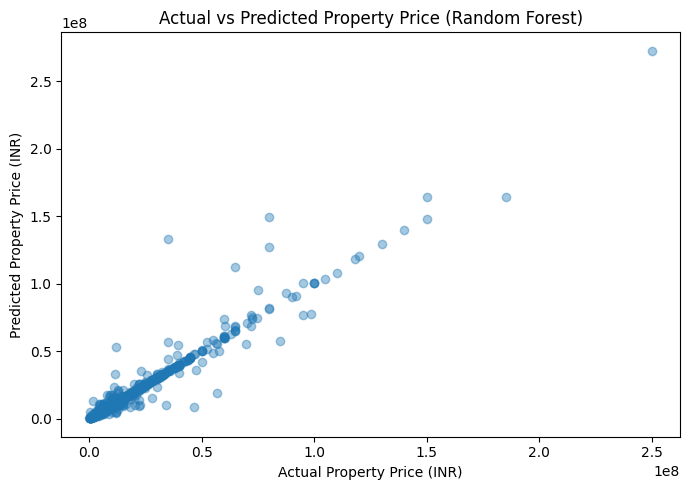

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred_rf, alpha=0.4)
plt.xlabel("Actual Property Price (INR)")
plt.ylabel("Predicted Property Price (INR)")
plt.title("Actual vs Predicted Property Price (Random Forest)")
plt.tight_layout()
plt.show()


The actual vs predicted price plot demonstrates a strong alignment between true and predicted property prices.
Most predictions lie close to the diagonal reference line, indicating high model accuracy.
Minor deviations at extreme price ranges are expected in real-world datasets and do not significantly affect overall performance.

In [15]:
import joblib

joblib.dump(rf, "real_estate_price_model.pkl")


['real_estate_price_model.pkl']

A regression-based machine learning model was developed to predict property prices using key property and locality features.
Linear Regression was used as a baseline model, while Random Forest Regressor was selected as the final model due to its superior performance.
The Random Forest model achieved an R² score of approximately 0.94 and a Mean Absolute Error of about ₹4.8 lakhs.
Feature importance analysis revealed rental yield as the most influential predictor, followed by location risk and property attributes.
The model’s predictions closely matched actual prices, validating its effectiveness for real-world real estate price estimation.